# 🎬 Analyse de sentiment — EDA & Baseline TF-IDF
## Notebook 1/2

**Auteur :** Diogo Almeida
**Dataset :** [Allociné Reviews](https://github.com/TheophileBlard/french-sentiment-analysis-with-bert)

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
DATA_RAW = Path('..') / 'data' / 'raw'
DATA_PROCESSED = Path('..') / 'data' / 'processed'
MODELS = Path('..') / 'models'
ASSETS = Path('..') / 'assets'
for d in [DATA_PROCESSED, MODELS, ASSETS]:
    d.mkdir(parents=True, exist_ok=True)

## 1. Chargement du corpus

In [2]:
df = pd.read_csv(DATA_RAW / 'allocine_dataset.csv')
print(f'Corpus : {len(df):,} critiques')
print(f'Colonnes : {df.columns.tolist()}')

# Harmoniser les noms de colonnes
# Le dataset utilise 'polarity' au lieu de 'label' et peut avoir 'review' ou 'text'
if 'polarity' in df.columns and 'label' not in df.columns:
    df['label'] = df['polarity']
    print('  → polarity renommé en label')
if 'review' not in df.columns and 'text' in df.columns:
    df['review'] = df['text']
    print('  → text renommé en review')

print(f'\nLabels :')
print(df['label'].value_counts())
if 'split' in df.columns:
    print(f'\nSplits :')
    print(df['split'].value_counts())

display(df.head())

Corpus : 200,000 critiques
Colonnes : ['film-url', 'review', 'polarity', 'split', 'label']

Labels :
label
0    100025
1     99975
Name: count, dtype: int64

Splits :
split
train    160000
test      20000
val       20000
Name: count, dtype: int64


,film-url,review,polarity,split,label
0,http://www.allocine.fr/film/fichefilm-25385/cr...,"Magnifique épopée, une belle histoire, touchan...",1,test,1
1,http://www.allocine.fr/film/fichefilm-1954/cri...,Je n'ai pas aimé mais pourtant je lui mets 2 é...,0,test,0
2,http://www.allocine.fr/film/fichefilm-135523/c...,Un dessin animé qui brille par sa féerie et se...,1,test,1
3,http://www.allocine.fr/film/fichefilm-61514/cr...,"Si c'est là le renouveau du cinéma français, c...",0,test,0
4,http://www.allocine.fr/film/fichefilm-260395/c...,Et pourtant on s’en Doutait !Second volet très...,0,test,0


## 2. EDA du corpus

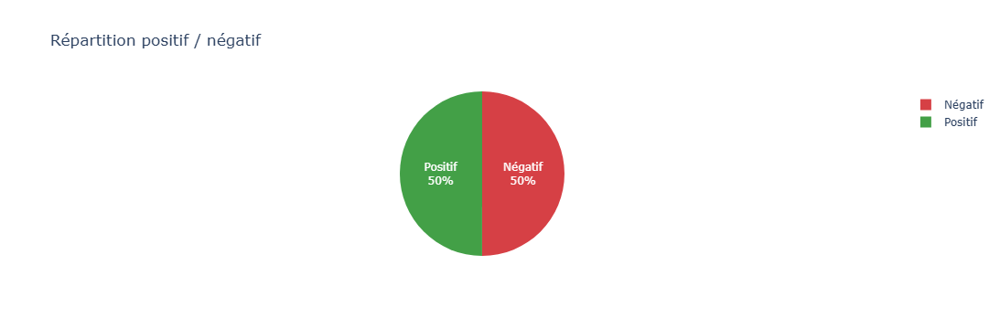

In [3]:
# Distribution des labels
df['sentiment'] = df['label'].map({0: 'Négatif', 1: 'Positif'})

fig = px.pie(df, names='sentiment', title='Répartition positif / négatif',
    color='sentiment',
    color_discrete_map={'Négatif': '#D64045', 'Positif': '#43A047'},
    template='plotly_white')
fig.update_traces(textinfo='percent+label')
fig.show()

Longueur (caractères) :
count    200000.0
mean        544.0
std         453.0
min           3.0
25%         196.0
50%         390.0
75%         773.0
max        2000.0
Name: text_length, dtype: float64

Nombre de mots :
count    200000.0
mean         92.0
std          76.0
min           1.0
25%          34.0
50%          66.0
75%         130.0
max         390.0
Name: word_count, dtype: float64


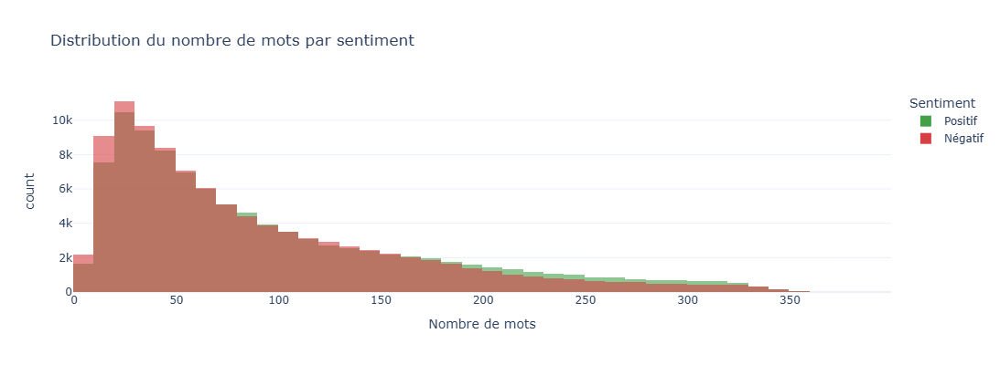

In [4]:
# Longueur des critiques
df['text_length'] = df['review'].astype(str).str.len()
df['word_count'] = df['review'].astype(str).str.split().str.len()

print(f'Longueur (caractères) :')
print(df['text_length'].describe().round(0))
print(f'\nNombre de mots :')
print(df['word_count'].describe().round(0))

fig = px.histogram(df, x='word_count', color='sentiment', barmode='overlay',
    title='Distribution du nombre de mots par sentiment',
    labels={'word_count': 'Nombre de mots', 'sentiment': 'Sentiment'},
    color_discrete_map={'Négatif': '#D64045', 'Positif': '#43A047'},
    template='plotly_white', opacity=0.6, nbins=50)
fig.update_layout(height=400)
fig.show()
fig.write_image(ASSETS / '01_distribution_longueur.png', scale=2)

In [5]:
# Mots les plus fréquents par sentiment
def top_words(texts, n=20):
    words = ' '.join(texts.astype(str)).lower().split()
    words = [w for w in words if len(w) > 3]
    return Counter(words).most_common(n)

print('Top 20 mots — Critiques POSITIVES :')
for word, count in top_words(df[df['label'] == 1]['review']):
    print(f'  {word}: {count:,}')

print('\nTop 20 mots — Critiques NÉGATIVES :')
for word, count in top_words(df[df['label'] == 0]['review']):
    print(f'  {word}: {count:,}')

Top 20 mots — Critiques POSITIVES :
  film: 122,480
  dans: 88,024
  pour: 67,356
  très: 63,714
  avec: 59,656
  mais: 54,706
  plus: 51,440
  bien: 45,963
  tout: 43,296
  c'est: 40,143
  sont: 39,085
  nous: 32,530
  comme: 28,387
  fait: 26,481
  cette: 25,547
  sans: 23,193
  aussi: 22,231
  même: 21,637
  voir: 19,903
  d'une: 19,364

Top 20 mots — Critiques NÉGATIVES :
  film: 101,822
  pour: 72,009
  dans: 71,956
  mais: 67,551
  c'est: 51,162
  plus: 47,396
  avec: 41,895
  tout: 41,556
  bien: 35,765
  très: 35,009
  sont: 34,970
  sans: 31,554
  même: 31,062
  fait: 26,474
  comme: 23,889
  cette: 20,723
  nous: 19,980
  faire: 19,936
  n'est: 19,728
  scénario: 19,678


In [6]:
# Exemples de critiques
for label, name in [(1, 'POSITIVE'), (0, 'NÉGATIVE')]:
    print(f'\n=== Exemple {name} ===')
    sample = df[df['label'] == label].sample(2, random_state=42)
    for _, row in sample.iterrows():
        text = str(row['review'])[:300]
        print(f'  "{text}..."\n')


=== Exemple POSITIVE ===
  "Magnifique ! Un film qui aide à mieux comprendre la violence qui a lieu en Algérie pour tous les européens fascinés par ce beau pays ou pour tous ceux qui sont en couple avec un(e) algérien(ne) et qui n'ont pas pu se rendre encore dans son pays a cause de cette même violence. Une belle musique, une ..."

  "Emportés dès les premières minutes du film dans un univers fantastique, nous découvrons en même temps que Chihiro le monde qu'a imaginé Hayao Miyazaki. Un monde patibulaire mais intriguant qui laisse libre recours au génie du maître de l'animation japonais. Comme à son habitude il traite des thémati..."


=== Exemple NÉGATIVE ===
  "À la vue de ses dernières réalisations plus pitoyables les unes que les autres (Mortuary, Toolbox Murders et j'en passe), on ne peut qu'être apeuré à l'idée de voir un nouveau film réalisé par ce vaurien de Tobe Hooper. Les adaptations de Richard Matheson ayant quasiment toutes été plus ou moins éco..."

  "A quoi bon ? Ce fi

## 3. Baseline TF-IDF

Pipeline classique : TF-IDF → modèle supervisé.
C'est le baseline à battre avec CamemBERT.

In [7]:
# Séparer train/test
if 'split' in df.columns:
    train = df[df['split'] == 'train'].copy()
    test = df[df['split'] == 'test'].copy()
    print(f'Split original — Train : {len(train):,} | Test : {len(test):,}')
else:
    train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
    print(f'Split manuel — Train : {len(train):,} | Test : {len(test):,}')

X_train_text = train['review'].astype(str)
X_test_text = test['review'].astype(str)
y_train = train['label'].astype(int)
y_test = test['label'].astype(int)

print(f'Distribution train : {y_train.value_counts().to_dict()}')
print(f'Distribution test : {y_test.value_counts().to_dict()}')

Split original — Train : 160,000 | Test : 20,000
Distribution train : {1: 80587, 0: 79413}
Distribution test : {0: 10408, 1: 9592}


In [8]:
# TF-IDF
print('Vectorisation TF-IDF...')
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f'Vocabulaire : {len(tfidf.vocabulary_):,} termes')
print(f'Matrice train : {X_train_tfidf.shape}')
print(f'Matrice test : {X_test_tfidf.shape}')

Vectorisation TF-IDF...
Vocabulaire : 50,000 termes
Matrice train : (160000, 50000)
Matrice test : (20000, 50000)


In [9]:
# Benchmark 3 modèles classiques
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
}

results = []
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    f1 = f1_score(y_test, y_pred)
    results.append({'Modèle': name, 'F1': round(f1, 4)})
    print(f'{name:25s} | F1 = {f1:.4f}')

df_results = pd.DataFrame(results).sort_values('F1', ascending=False)
display(df_results)

Logistic Regression       | F1 = 0.9377
Linear SVM                | F1 = 0.9392
Naive Bayes               | F1 = 0.9187


,Modèle,F1
1,Linear SVM,0.9392
0,Logistic Regression,0.9377
2,Naive Bayes,0.9187


Meilleur baseline : Linear SVM

              precision    recall  f1-score   support

     Négatif       0.95      0.94      0.94     10408
     Positif       0.94      0.94      0.94      9592

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



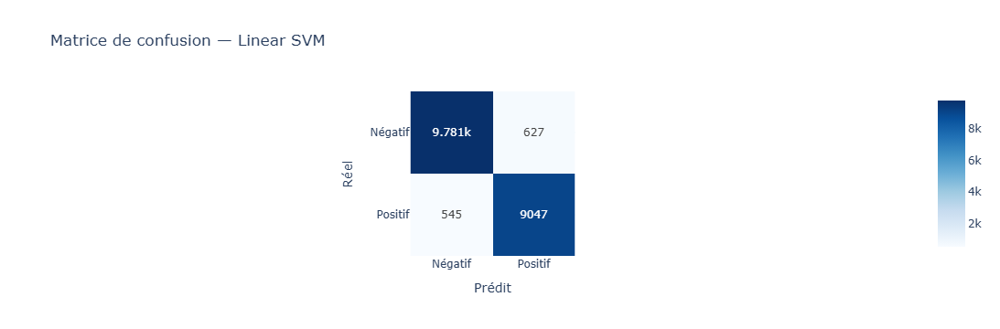

In [10]:
# Meilleur modèle baseline — rapport détaillé
best_name = df_results.iloc[0]['Modèle']
best_model = models[best_name]
y_pred = best_model.predict(X_test_tfidf)

print(f'Meilleur baseline : {best_name}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Négatif", "Positif"])}')

cm = confusion_matrix(y_test, y_pred)
fig = px.imshow(cm, text_auto=True, title=f'Matrice de confusion — {best_name}',
    labels=dict(x='Prédit', y='Réel'),
    x=['Négatif', 'Positif'], y=['Négatif', 'Positif'],
    color_continuous_scale='Blues', template='plotly_white')
fig.show()
fig.write_image(ASSETS / '02_confusion_baseline.png', scale=2)

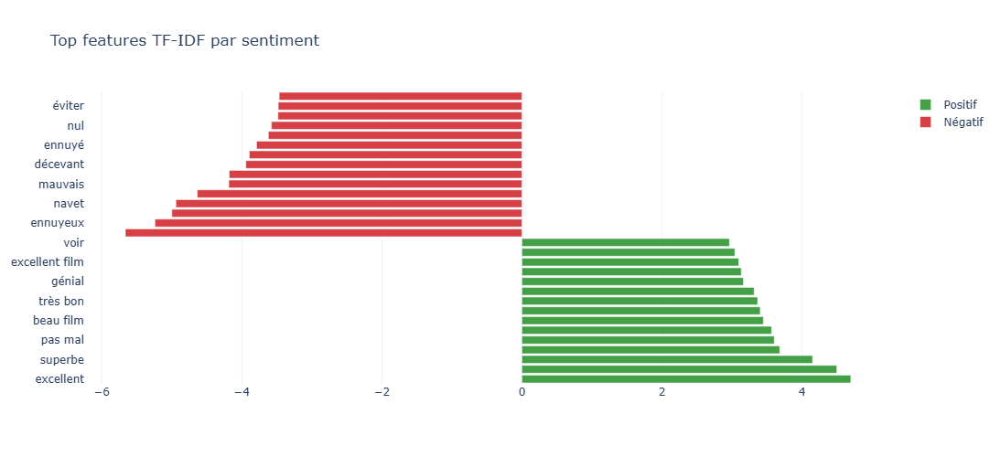

In [11]:
# Top features TF-IDF par classe
if hasattr(best_model, 'coef_'):
    feature_names = tfidf.get_feature_names_out()
    coefs = best_model.coef_[0] if best_model.coef_.ndim > 1 else best_model.coef_
    
    top_pos = pd.Series(coefs, index=feature_names).nlargest(15)
    top_neg = pd.Series(coefs, index=feature_names).nsmallest(15)
    
    fig = go.Figure()
    fig.add_trace(go.Bar(x=top_pos.values, y=top_pos.index, orientation='h',
        name='Positif', marker_color='#43A047'))
    fig.add_trace(go.Bar(x=top_neg.values, y=top_neg.index, orientation='h',
        name='Négatif', marker_color='#D64045'))
    fig.update_layout(title='Top features TF-IDF par sentiment',
        template='plotly_white', height=500, barmode='relative')
    fig.show()
    fig.write_image(ASSETS / '03_top_features_tfidf.png', scale=2)

## 4. Analyse d'erreurs du baseline

In [12]:
# Exemples d'erreurs
test_with_pred = test.copy()
test_with_pred['pred'] = y_pred
errors = test_with_pred[test_with_pred['label'] != test_with_pred['pred']]

print(f'Erreurs : {len(errors):,} / {len(test):,} ({len(errors)/len(test)*100:.1f}%)')

print(f'\n--- Faux positifs (prédit positif, réellement négatif) ---')
fp = errors[(errors['pred'] == 1) & (errors['label'] == 0)]
for _, row in fp.sample(min(3, len(fp)), random_state=42).iterrows():
    print(f'  "{str(row["review"])[:200]}..."\n')

print(f'--- Faux négatifs (prédit négatif, réellement positif) ---')
fn = errors[(errors['pred'] == 0) & (errors['label'] == 1)]
for _, row in fn.sample(min(3, len(fn)), random_state=42).iterrows():
    print(f'  "{str(row["review"])[:200]}..."\n')

Erreurs : 1,172 / 20,000 (5.9%)

--- Faux positifs (prédit positif, réellement négatif) ---
  "Excellent film, avec un Daniel Day Lewis des grands jours (quand ne joue-t-il pas bien ?). Quatre jeunes gens sont accusés d'un attentat qu'ils n'ont pas commis et, bien que la police soit au courant ..."

  "C'est dommage d'aller voir un film et de ne (presque) rien y comprendre. Surtout quand c'est un film qui parle de politique. On retourne donc dix ans en arrière, en 2003. A ce moment-là, au ministère ..."

  "Pinocchio le robot est une aventure à ne pas manquer (en famille), mais sinon c'est pas un film très original et bon non plus! Une bonne adaptation de Pinocchio avec un futur qu'on avez imaginé, c'est..."

--- Faux négatifs (prédit négatif, réellement positif) ---
  "Après "J'ai tué ma mère" qui fut son coup d'essai, Xavier Dolan réalise avec "Les amours imaginaires" un coup de maître. Le jeune prodige canadien frôle la perfection. Il réussit à faire passer le spe..."

  "Ce film es

## 5. Sauvegarde

In [13]:
# Sauvegarder le meilleur baseline
joblib.dump(best_model, MODELS / 'baseline_model.pkl')
joblib.dump(tfidf, MODELS / 'tfidf_vectorizer.pkl')

baseline_score = df_results.iloc[0]['F1']
joblib.dump({'name': best_name, 'f1': baseline_score}, MODELS / 'baseline_results.pkl')

print(f'Baseline sauvegardé : {best_name} (F1 = {baseline_score})')

Baseline sauvegardé : Linear SVM (F1 = 0.9392)


---

*Notebook réalisé par Diogo Almeida — Septembre 2026*